# Segment Anything with SAM 3 — Images & Videos

Segment **every instance** of any concept in an image or video using a text
prompt like `"cat"`, `"red car"`, or `"person wearing a hat"`.

**Prerequisites (do once before running this notebook):**
1. Request access to the SAM 3 checkpoints at
   https://huggingface.co/facebook/sam3 (gated model — usually approved fast).
2. Create an HF access token at https://huggingface.co/settings/tokens and
   paste it into `HF_TOKEN` in cell 1.
3. **Use a GPU runtime** (Runtime → Change runtime type → T4 GPU or better).
   SAM 3 has ~848M parameters; CPU inference will be very slow.
4. Make sure you have recent versions of `transformers`, `accelerate`,
   `huggingface_hub`, `Pillow`, `matplotlib`, and `opencv-python` installed.
   On Colab these are already there; if not, install them in your environment
   first.

**How to use:**
- **Cell 1**: run once per session. Loads the SAM 3 image + video models and
  defines the helper functions. Slow the first time (downloads ~3.4 GB of
  weights), fast on subsequent runs.
- **Cell 2**: run every time you want to segment something. Prompts you to
  upload a file (image *or* video) and asks for the text prompt.


In [3]:
!pip install -q --upgrade "transformers>=4.57.0" accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 108.7 MB/s eta 0:00:00


In [1]:
!pip show transformers


Name: transformers
Version: 5.7.0
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: peft, sentence-transformers


In [ ]:
# === Cell 1: Load SAM 3 and define helpers (run once per session) ===
# Re-running this cell is cheap: if the models are already loaded into
# memory, we skip the download/load step.

# --- 1. Authenticate with Hugging Face (SAM 3 weights are gated) ---
HF_TOKEN = ""  # paste your token from https://huggingface.co/settings/tokens
from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=False)

# --- 2. Imports ---
import os, numpy as np, torch, matplotlib.pyplot as plt
from PIL import Image
from transformers import (
    Sam3Model, Sam3Processor,            # for images
    Sam3VideoModel, Sam3VideoProcessor,  # for videos
)

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("WARNING: no GPU detected — inference will be slow.")

# --- 3. Load both models (only the first time — cached afterwards). ---
# Globals are checked so accidentally re-running this cell is fast.
if "image_model" not in globals():
    print(f"Loading SAM 3 (image) onto {device}...")
    image_model     = Sam3Model.from_pretrained("facebook/sam3").to(device).eval()
    image_processor = Sam3Processor.from_pretrained("facebook/sam3")
else:
    print("SAM 3 image model already loaded — skipping.")

if "video_model" not in globals():
    print(f"Loading SAM 3 (video) onto {device}...")
    # bfloat16 keeps the video model in VRAM on a T4-class GPU.
    video_model     = Sam3VideoModel.from_pretrained("facebook/sam3").to(device, dtype=torch.bfloat16).eval()
    video_processor = Sam3VideoProcessor.from_pretrained("facebook/sam3")
else:
    print("SAM 3 video model already loaded — skipping.")

print("Models ready.")


# --- 4. Helpers ---

VIDEO_EXTS = {".mp4", ".mov", ".avi", ".webm", ".mkv", ".m4v"}


def segment_image(image_path, text_prompt, score_threshold=0.5, out_dir="sam3_outputs"):
    """Run SAM 3 on a single image and save + display masks."""
    image = Image.open(image_path).convert("RGB")

    # Tokenize text + preprocess image, then run the detector.
    inputs = image_processor(images=image, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = image_model(**inputs)

    # Convert raw logits -> binary masks at the original image size.
    results = image_processor.post_process_instance_segmentation(
        outputs,
        threshold=score_threshold,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]
    masks  = results["masks"]
    boxes  = results["boxes"]
    scores = results["scores"]
    n = len(masks)
    print(f"Found {n} instance(s) of \"{text_prompt}\".")

    # 3-panel figure: original / overlay / combined-mask.
    img_np = np.array(image)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_np); axes[0].set_title("Original"); axes[0].axis("off")

    axes[1].imshow(img_np)
    rng = np.random.default_rng(0)
    for i in range(n):
        m = masks[i].cpu().numpy().astype(bool)
        c = rng.random(3)
        overlay = np.zeros((*m.shape, 4)); overlay[m] = [*c, 0.5]
        axes[1].imshow(overlay)
        x0, y0, x1, y1 = boxes[i].cpu().numpy()
        axes[1].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, edgecolor=c, linewidth=2))
        axes[1].text(x0, max(y0 - 5, 0), f"{scores[i]:.2f}",
                     color="white", fontsize=10,
                     bbox=dict(facecolor=c, alpha=0.7, pad=1))
    axes[1].set_title(f"Overlay: \"{text_prompt}\" ({n} found)"); axes[1].axis("off")

    if n > 0:
        combined = masks.cpu().numpy().any(axis=0)
        axes[2].imshow(combined, cmap="gray")
    else:
        axes[2].imshow(np.zeros_like(img_np[..., 0]), cmap="gray")
    axes[2].set_title("All masks"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

    # Save: per-instance PNG masks + RGBA cutout (transparent background).
    os.makedirs(out_dir, exist_ok=True)
    for i in range(n):
        m = (masks[i].cpu().numpy().astype(np.uint8)) * 255
        Image.fromarray(m).save(f"{out_dir}/mask_{i:02d}_score{scores[i]:.2f}.png")
    if n > 0:
        combined = masks.cpu().numpy().any(axis=0)
        rgba = np.dstack([img_np, (combined * 255).astype(np.uint8)])
        Image.fromarray(rgba, mode="RGBA").save(f"{out_dir}/cutout.png")
    print(f"Saved outputs to ./{out_dir}/")


def segment_video(video_path, text_prompt, score_threshold=0.5,
                  out_dir="sam3_outputs", preview_frames=4):
    """Run SAM 3 on a video. Tracks every instance of the concept across frames
    and writes an overlay video to disk."""
    import cv2

    # 1. Load all frames into memory using OpenCV (no extra deps needed).
    #    For very long videos, you'd want to process in chunks — but for
    #    typical clips this is fine.
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    video_frames = []
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        # OpenCV gives BGR; SAM 3 expects RGB.
        video_frames.append(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    cap.release()
    n_frames = len(video_frames)
    print(f"Loaded {n_frames} frames from {video_path} at {fps:.1f} fps.")

    # 2. Initialize a video session and attach the text prompt.
    inference_session = video_processor.init_video_session(
        video=video_frames,
        inference_device=device,
        processing_device="cpu",
        video_storage_device="cpu",
        dtype=torch.bfloat16,
    )
    video_processor.add_text_prompt(
        inference_session=inference_session,
        text=text_prompt,
    )

    # 3. Propagate through the video. Each iteration yields a
    #    Sam3VideoSegmentationOutput for one frame (not necessarily in order),
    #    which we post-process into masks/boxes/scores at original resolution
    #    and key by frame index.
    print("Tracking through video...")
    outputs_per_frame = {}
    with torch.no_grad():
        for model_outputs in video_model.propagate_in_video_iterator(
            inference_session=inference_session,
        ):
            processed = video_processor.postprocess_outputs(inference_session, model_outputs)
            outputs_per_frame[model_outputs.frame_idx] = processed
    print(f"Done. Got results for {len(outputs_per_frame)} frames.")

    # 4. Render an overlay video. Object IDs are stable across frames, so
    #    using them as the key for color gives each instance a consistent color.
    os.makedirs(out_dir, exist_ok=True)
    out_path = f"{out_dir}/segmented_video.mp4"

    h, w = video_frames[0].shape[:2]
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    rng = np.random.default_rng(0)
    color_for_id = {}
    def color(obj_id):
        if obj_id not in color_for_id:
            color_for_id[obj_id] = (rng.random(3) * 255).astype(np.uint8)
        return color_for_id[obj_id]

    preview_imgs = []
    for i, frame in enumerate(video_frames):
        canvas = np.array(frame).copy()
        result = outputs_per_frame.get(i)
        if result is not None:
            obj_ids = result["object_ids"]
            masks   = result["masks"]   # (num_objects, H, W) at original resolution
            scores  = result["scores"]
            # Apply score threshold here (the session-level threshold is
            # applied during tracking, but we double-check per-frame).
            obj_ids_t = obj_ids.tolist() if hasattr(obj_ids, "tolist") else list(obj_ids)
            scores_t  = scores.tolist() if hasattr(scores, "tolist") else list(scores)
            for j, (oid, sc) in enumerate(zip(obj_ids_t, scores_t)):
                if sc < score_threshold:
                    continue
                m_np = masks[j].cpu().numpy().astype(bool) if hasattr(masks[j], "cpu") else np.asarray(masks[j]).astype(bool)
                c = color(int(oid))
                # Blend the mask color into the frame at 50% opacity.
                canvas[m_np] = (0.5 * canvas[m_np] + 0.5 * c).astype(np.uint8)
        # cv2 wants BGR.
        writer.write(cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))
        if i < preview_frames:
            preview_imgs.append(canvas)
    writer.release()
    print(f"Saved overlay video to {out_path}")

    # 5. Show a few preview frames inline so you can sanity-check without
    #    downloading the full video.
    if preview_imgs:
        fig, axes = plt.subplots(1, len(preview_imgs),
                                 figsize=(5 * len(preview_imgs), 5))
        if len(preview_imgs) == 1:
            axes = [axes]
        for ax, img, idx in zip(axes, preview_imgs, range(len(preview_imgs))):
            ax.imshow(img); ax.set_title(f"Frame {idx}"); ax.axis("off")
        plt.tight_layout(); plt.show()


def segment(file_path, text_prompt, score_threshold=0.5):
    """Dispatch to image or video segmentation based on file extension."""
    ext = os.path.splitext(file_path)[1].lower()
    if ext in VIDEO_EXTS:
        segment_video(file_path, text_prompt, score_threshold)
    else:
        segment_image(file_path, text_prompt, score_threshold)


print("Helpers ready. Run cell 2 to upload a file and segment.")


Loading SAM 3 (image) onto cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Loading SAM 3 (video) onto cuda...


Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Models ready.
Helpers ready. Run cell 2 to upload a file and segment.


Upload an image (jpg/png/...) or a video (mp4/mov/...).


Saving WhatsApp Video 2026-05-04 at 2.58.12 PM.mp4 to WhatsApp Video 2026-05-04 at 2.58.12 PM (2).mp4
What would you like to segment? (e.g. 'cat', 'red car'): Humans
Loaded 60 frames from WhatsApp Video 2026-05-04 at 2.58.12 PM (2).mp4 at 30.2 fps.
Tracking through video...


[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


Done. Got results for 60 frames.
Saved overlay video to sam3_outputs/segmented_video.mp4


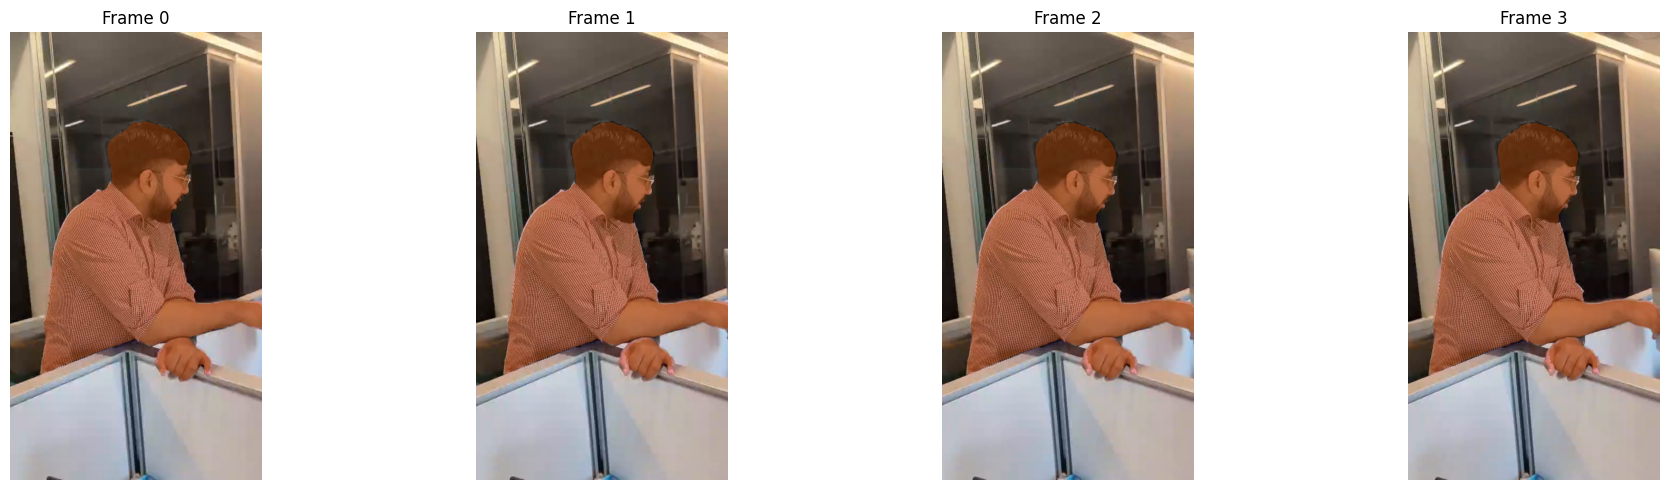

In [3]:
# === Cell 2: Upload your image or video, type a prompt, segment ===
from google.colab import files

print("Upload an image (jpg/png/...) or a video (mp4/mov/...).")
uploaded = files.upload()
file_path = next(iter(uploaded))

# Tweak these as you like, then re-run this cell to try new prompts
# without re-uploading.
TEXT_PROMPT = input("What would you like to segment? (e.g. 'cat', 'red car'): ").strip()
SCORE_THRESHOLD = 0.5  # lower = more detections, higher = stricter

segment(file_path, TEXT_PROMPT, SCORE_THRESHOLD)
